# Загрузка ресторана по получасам — Архангельское, май–сентябрь 2026

Два графика со средней загрузкой, будни и выходные отдельно:

1. **Заказы за полчаса** — среднее за день по каналам: зал (чеки со столом), агрегаторы (выполненные заказы Вендора), своя доставка (чеки r_keeper).
2. **Посадка зала** — доля занятых столов от работающих: линия — среднее, полоса — от 10% до 90% дней.

Данные — `data/raw/` (см. README), расчёт — `load_profile.py`. Запуск: открыть ноутбук из папки `analysis/` и выполнить все ячейки.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from load_profile import CHANNELS, half_hour_profile

SINCE, UNTIL = "2026-05-01", "2026-10-01"
p = half_hour_profile(SINCE, UNTIL)
DAYS = {False: "будни", True: "выходные"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
p.round(1)

зал  агрегаторы  своя доставка  всего  посадка, %  p10, %  \
weekend slot                                                                
False   10:00   3.3         0.4            0.3    4.0         2.3     0.0   
        10:30   2.8         0.4            0.2    3.4         8.1     2.0   
        11:00   3.5         0.4            0.1    4.0        11.8     5.8   
        11:30   3.2         0.7            0.2    4.0        15.2     7.5   
        12:00   4.1         0.8            0.1    5.0        17.0     7.5   
        12:30   4.7         0.7            0.2    5.6        18.1     8.0   
        13:00   5.6         0.8            0.2    6.6        21.2    11.2   
        13:30   6.0         0.8            0.2    6.9        23.1    13.7   
        14:00   5.8         0.6            0.1    6.6        26.4    16.7   
        14:30   5.8         0.7            0.2    6.8        27.9    15.4   
        15:00   5.7         0.7            0.1    6.5        28.6    15.7   
        15:30   5.6         0.5            0.2    6.3        27.0    15.5   
        16:00   5.2         0.7            0.2    6.1        26.5    14.6   
        16:30   4.8         0.9            0.2    5.9        25.6    13.7   
        17:00   4.6         0.8            0.3    5.7        25.0    13.7   
        17:30   4.6         0.8            0.2    5.6        23.4    13.0   
        18:00   4.4         1.0            0.3    5.7        23.4    11.8   
        18:30   4.4         1.2            0.4    5.9        23.1    13.7   
        19:00   4.4         0.9            0.3    5.7        23.4    11.8   
        19:30   4.0         1.0            0.3    5.4        24.5    11.8   
        20:00   3.8         0.9            0.2    5.0        23.9    12.5   
        20:30   3.4         0.8            0.2    4.4        22.7    11.2   
        21:00   2.7         0.4            0.1    3.2        20.5    10.0   
        21:30   2.4         0.2            0.1    2.7        16.7     6.0   
        22:00   1.6         0.0            0.0    1.6        12.9     5.4   
        22:30   0.2         0.0            0.0    0.2         8.0     0.0   
True    10:00   5.2         0.6            0.2    6.1         2.9     0.0   
        10:30   4.8         0.6            0.1    5.5        11.1     5.0   
        11:00   5.7         0.8            0.0    6.5        16.0     9.0   
        11:30   5.8         0.7            0.2    6.8        20.8    13.5   
        12:00   6.8         0.9            0.2    7.9        22.4    11.6   
        12:30   7.7         1.1            0.2    9.0        24.4    16.0   
        13:00   9.1         1.0            0.2   10.2        28.4    19.8   
        13:30   9.1         1.0            0.4   10.5        33.5    22.5   
        14:00   9.2         0.8            0.3   10.3        35.7    23.5   
        14:30   9.4         1.1            0.4   10.9        36.5    23.4   
        15:00  11.6         1.3            0.2   13.2        38.6    22.4   
        15:30  10.5         1.1            0.3   11.9        41.7    26.8   
        16:00  10.0         1.0            0.3   11.3        41.1    28.8   
        16:30   9.5         1.1            0.4   10.9        39.1    26.2   
        17:00   9.6         1.2            0.3   11.1        40.1    27.2   
        17:30   8.7         1.2            0.4   10.3        40.4    24.7   
        18:00   8.2         1.4            0.5   10.1        39.6    26.2   
        18:30   7.5         1.7            0.3    9.5        39.0    26.6   
        19:00   7.2         1.2            0.2    8.6        36.4    22.4   
        19:30   5.9         1.0            0.2    7.2        34.1    21.2   
        20:00   5.3         0.8            0.1    6.2        30.5    17.2   
        20:30   4.1         0.9            0.1    5.0        27.7    13.9   
        21:00   3.3         0.5            0.2    4.0        21.9     9.6   
        21:30   2.5         0.1            0.1    2.8        14.9     5.6   
        22:0

## 1. Заказы за полчаса

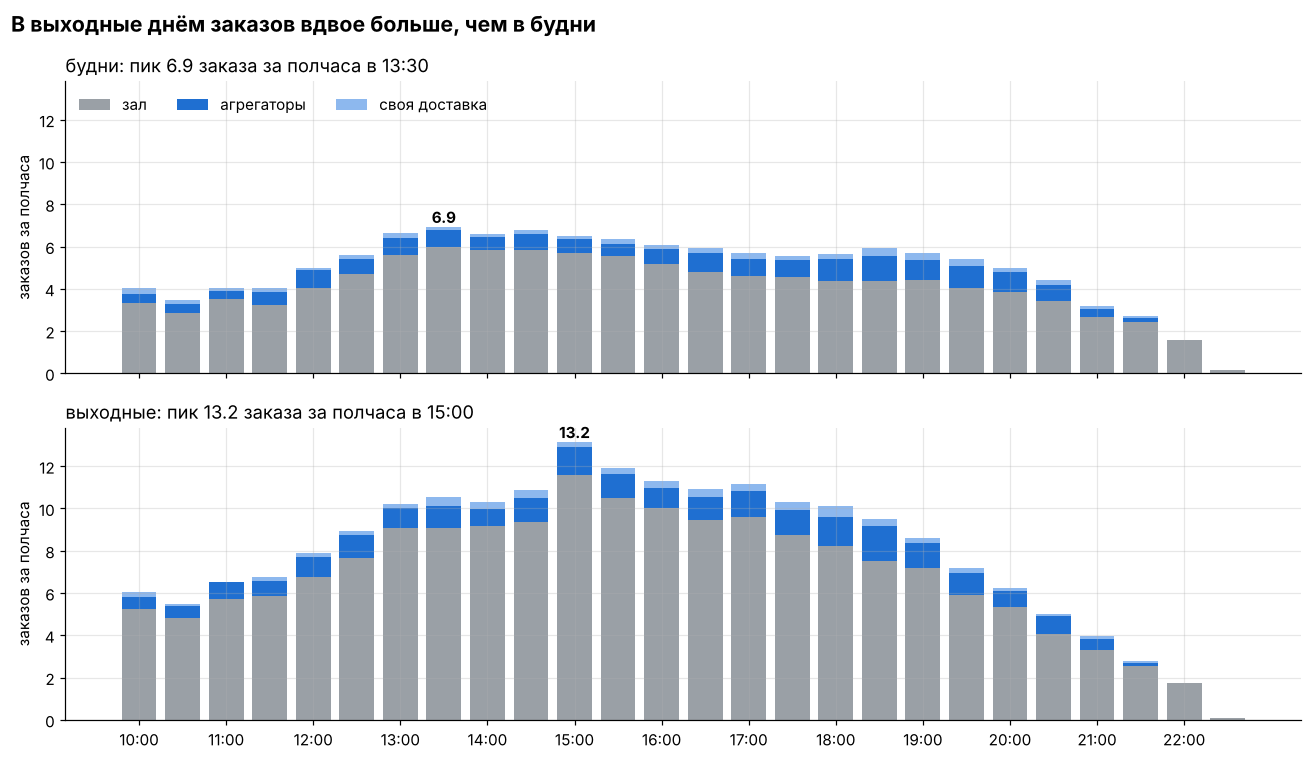

In [2]:
colors = {"зал": "#9aa0a6", "агрегаторы": "#1f6fd1", "своя доставка": "#8db8ee"}
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True)
for ax, (weekend, name) in zip(axes, DAYS.items()):
    d = p.loc[weekend]
    bottom = pd.Series(0.0, index=d.index)
    for ch in CHANNELS:
        ax.bar(d.index, d[ch], bottom=bottom, color=colors[ch], label=ch, width=0.8)
        bottom += d[ch]
    peak = d["всего"].idxmax()
    ax.annotate(f"{d.loc[peak, 'всего']:.1f}", (peak, d.loc[peak, "всего"]), ha="center", va="bottom", fontweight="bold")
    ax.set_title(f"{name}: пик {d.loc[peak, 'всего']:.1f} заказа за полчаса в {peak}", loc="left")
    ax.set_ylabel("заказов за полчаса")
axes[0].legend(loc="upper left", ncol=3, frameon=False)
axes[1].set_xticks(range(0, len(d.index), 2))
axes[1].set_xticklabels(d.index[::2])
fig.suptitle("В выходные днём заказов вдвое больше, чем в будни", x=0.01, ha="left", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [3]:
share = p.groupby(level=0)[CHANNELS].sum()
share = share.div(share.sum(axis=1), axis=0).mul(100).round(0).rename(index=DAYS)
print("Доля заказов по каналам, %:")
share

Доля заказов по каналам, %:


,зал,агрегаторы,своя доставка
weekend,,,
будни,83.0,13.0,4.0
выходные,86.0,11.0,3.0


## 2. Посадка зала

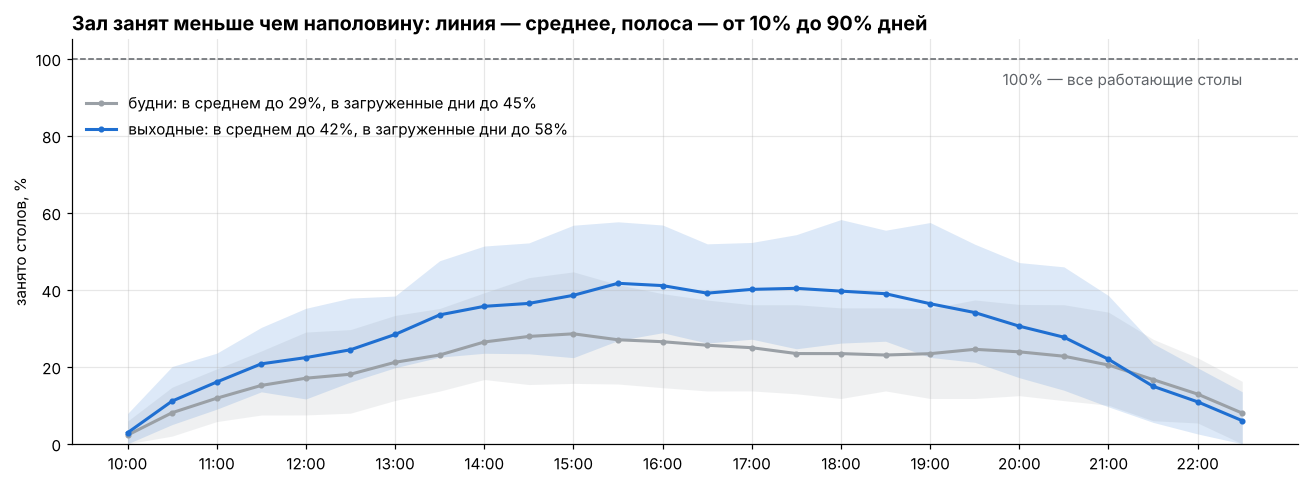

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
style = {False: "#9aa0a6", True: "#1f6fd1"}
for weekend, name in DAYS.items():
    d = p.loc[weekend]
    ax.fill_between(d.index, d["p10, %"], d["p90, %"], color=style[weekend], alpha=0.15, linewidth=0)
    ax.plot(d.index, d["посадка, %"], color=style[weekend], linewidth=2, marker="o", markersize=3,
            label=f"{name}: в среднем до {d['посадка, %'].max():.0f}%, в загруженные дни до {d['p90, %'].max():.0f}%")
ax.axhline(100, color="#5f6368", linestyle="--", linewidth=1)
ax.text(len(d.index) - 1, 97, "100% — все работающие столы", ha="right", va="top", color="#5f6368")
ax.set_ylim(0, 105)
ax.set_ylabel("занято столов, %")
ax.set_xticks(range(0, len(d.index), 2))
ax.set_xticklabels(d.index[::2])
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.9), frameon=False)
ax.set_title("Зал занят меньше чем наполовину: линия — среднее, полоса — от 10% до 90% дней", loc="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

**Как читать.** Столбики первого графика — сколько заказов в среднем приходит за каждые полчаса: в будни нагрузка ровная с 13 до 20, в выходные пик 13–18. Доставка (синие части) — 14–17% заказов, её пик в 18:00–19:00 приходится на спад зала. Второй график: даже в 10% самых загруженных выходных занято не больше ~58% работающих столов — зал не ограничивает выручку.

Оговорки: чек открывают чуть позже прихода гостя и закрывают чуть раньше ухода, поэтому реальная посадка на 10–15% выше. «Работающие столы» — столы, на которых были чеки в этом месяце; веранды считаются только в дни, когда на них были гости.

## 3. Все рестораны: чеки по часам

Для остальных ресторанов есть только витрина r_keeper по часам, поэтому здесь иначе, чем выше:
- **по часам, а не по получасам**, по часу открытия чека;
- **все оплаченные чеки вместе** — зал, навынос и доставка: поле канала в витрине сломано (с 2026 года почти всё помечено «Доставка»);
- **посадку зала** посчитать нельзя: нужны чеки со столами и временем закрытия, как в выгрузке Архангельского (`riga_orders.parquet`). Её можно собрать тем же скриптом `build_riga_pilot.py` для каждого ресторана.

PERM — с 10.06.2026 (открытие), остальные — май–сентябрь 2026. Шкала у всех панелей одна, чтобы было видно и форму, и объём.

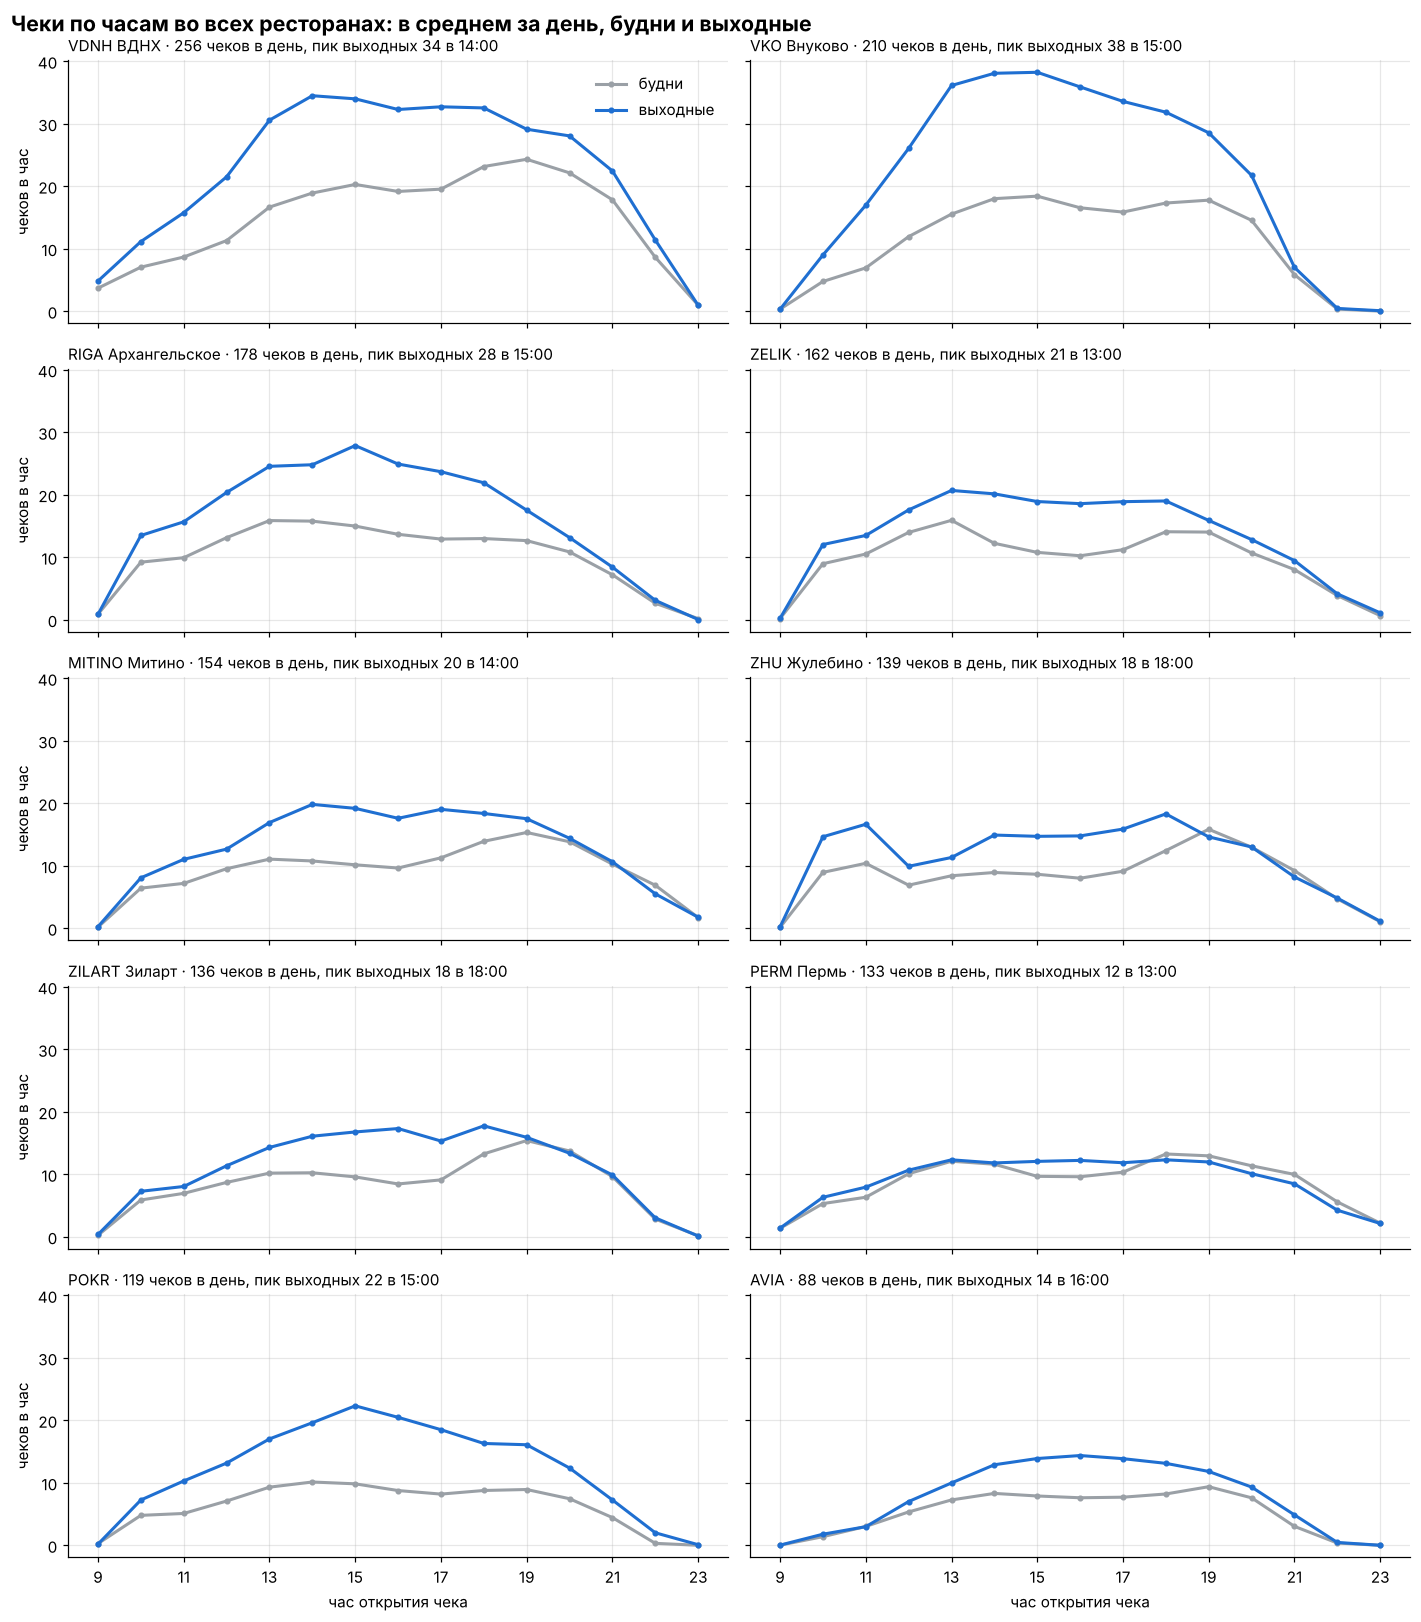

In [5]:
from load_profile import hourly_by_restaurant

NAMES = {"RIGA": "Архангельское", "ZHU": "Жулебино", "ZILART": "Зиларт", "VKO": "Внуково",
         "MITINO": "Митино", "VDNH": "ВДНХ", "PERM": "Пермь"}
r = hourly_by_restaurant(SINCE, UNTIL)
daily = r.groupby(["rest", "weekend"])["checks"].sum().unstack().rename(columns=DAYS)
per_day = (daily["будни"] * 5 + daily["выходные"] * 2) / 7          # средняя неделя
order = per_day.sort_values(ascending=False).index

fig, axes = plt.subplots(5, 2, figsize=(13, 15), sharex=True, sharey=True)
for ax, rest in zip(axes.flat, order):
    for weekend, name in DAYS.items():
        d = r[(r["rest"] == rest) & (r["weekend"] == weekend)]
        ax.plot(d["hour"], d["checks"], color=style[weekend], linewidth=2, marker="o", markersize=3, label=name)
    we = r[(r["rest"] == rest) & r["weekend"]].set_index("hour")["checks"]
    ax.set_title(f"{rest} {NAMES.get(rest, '')}".strip() + f" · {per_day[rest]:.0f} чеков в день, "
                 f"пик выходных {we.max():.0f} в {we.idxmax()}:00", loc="left", fontsize=10)
    ax.set_xticks(range(9, 24, 2))
for ax in axes[:, 0]:
    ax.set_ylabel("чеков в час")
for ax in axes[-1]:
    ax.set_xlabel("час открытия чека")
axes[0, 0].legend(frameon=False)
fig.suptitle("Чеки по часам во всех ресторанах: в среднем за день, будни и выходные", x=0.01, ha="left",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [6]:
def summary(rest):
    out = {}
    for weekend, name in DAYS.items():
        d = r[(r["rest"] == rest) & (r["weekend"] == weekend)].set_index("hour")["checks"]
        out[f"чеков в день, {name}"] = round(d.sum())
        out[f"пиковый час, {name}"] = f"{d.idxmax()}:00"
        out[f"10–11 ч от пика, {name}, %"] = round(d.loc[10] / d.max() * 100)
    return out

pd.DataFrame({rest: summary(rest) for rest in order}).T

,"чеков в день, будни","пиковый час, будни","10–11 ч от пика, будни, %","чеков в день, выходные","пиковый час, выходные","10–11 ч от пика, выходные, %"
VDNH,222,19:00,29,342,14:00,32
VKO,164,15:00,26,324,15:00,23
RIGA,153,13:00,58,240,15:00,48
ZELIK,145,13:00,56,203,13:00,58
MITINO,138,19:00,42,193,14:00,41
ZHU,126,19:00,56,173,18:00,80
ZILART,124,19:00,38,167,18:00,41
PERM,132,18:00,40,136,13:00,51
POKR,93,14:00,47,183,15:00,32
AVIA,77,19:00,15,116,16:00,12


**Как читать.** Последняя колонка таблицы — сколько чеков в 10–11 утра от пикового часа: чем меньше, тем больше утренний провал и тем больше смысла в сдвинутом начале смен. Пиковый час у ресторанов разный — у торговых центров и у загородных ресторанов профили отличаются, поэтому шаблоны смен нужно подбирать для каждого ресторана отдельно.